# Limpieza y Procesamiento del Dataset de Instacart para Filtrado Colaborativo

In [1]:
import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
print("Carga de datasets")
start_time = time.time()

dtypes_orders = {"order_id": "int32", "user_id": "int32"}
dtypes_op = {"order_id": "int32", "product_id": "int32"}

orders = pd.read_csv("orders.csv", usecols=["order_id", "user_id"], dtype=dtypes_orders)
order_products = pd.read_csv("order_products__prior.csv", usecols=["order_id", "product_id"], dtype=dtypes_op)
products_df = pd.read_csv("products.csv", usecols=["product_id", "product_name"])

print(f"orders: {orders.shape}, order_products: {order_products.shape}")

Carga de datasets
orders: (3421083, 2), order_products: (32434489, 2)


## 1. Cruce de Tablas y Generación de Interacciones
Unimos las transacciones para asociar directamente a cada usuario con los productos que ha comprado, generando un "rating implícito" basado en la frecuencia de compra.

In [3]:
df_merged = pd.merge(order_products, orders, on="order_id", how="inner")

del orders, order_products

print("Generando matriz de interacciones (Agrupación)")
interactions = (
    df_merged.groupby(['user_id', 'product_id'], sort=False)
    .size()
    .reset_index(name='purchase_count')
)
interactions['purchase_count'] = interactions['purchase_count'].astype('uint16')

del df_merged

print(f"Total de interacciones únicas (Usuario-Producto): {len(interactions):,}")

Generando matriz de interacciones (Agrupación)
Total de interacciones únicas (Usuario-Producto): 13,307,953


## 2. Análisis Exploratorio Visual (EDA)
Antes de filtrar, analizamos la distribución de las compras para identificar el nivel de dispersión en la matriz. Esto nos permitirá establecer umbrales lógicos para mitigar el problema del *Cold Start*.

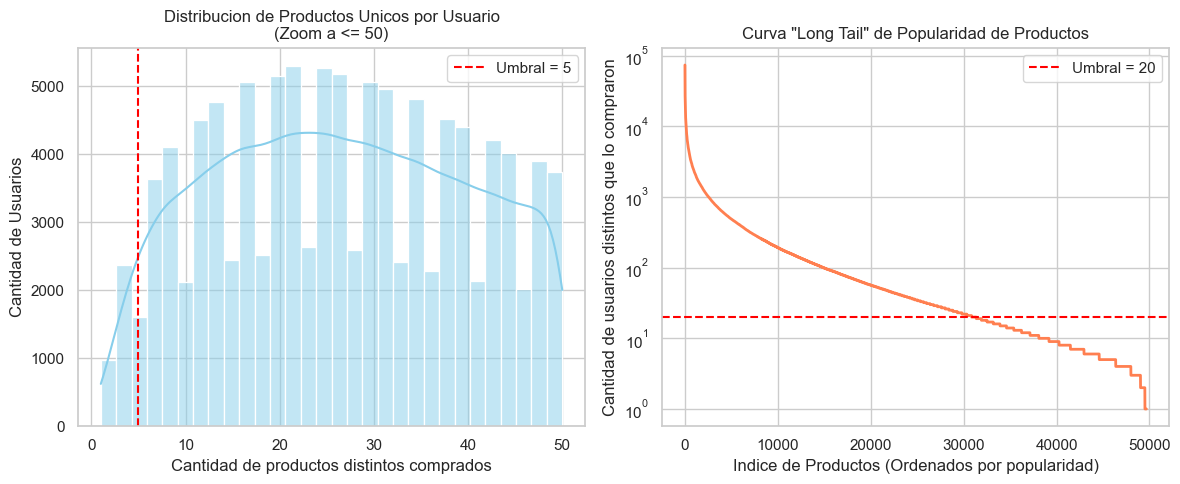

In [4]:
# Calcular compras por usuario y por producto
user_activity = interactions.groupby('user_id').size()
product_popularity = interactions.groupby('product_id').size()

min_compras_usuario = 5
min_compras_producto = 20

fig, axes = plt.subplots(1, 2)

# Grafica 1: Distribucion de compras por usuario
sns.histplot(user_activity[user_activity <= 50], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(min_compras_usuario, color='red', linestyle='--', label=f'Umbral = {min_compras_usuario}')
axes[0].set_title('Distribucion de Productos Unicos por Usuario\n(Zoom a <= 50)')
axes[0].set_xlabel('Cantidad de productos distintos comprados')
axes[0].set_ylabel('Cantidad de Usuarios')
axes[0].legend()

# Grafica 2: Curva Long Tail de Productos
product_popularity_sorted = product_popularity.sort_values(ascending=False).values
axes[1].plot(product_popularity_sorted, color='coral', linewidth=2)
axes[1].axhline(min_compras_producto, color='red', linestyle='--', label=f'Umbral = {min_compras_producto}')
axes[1].set_title('Curva "Long Tail" de Popularidad de Productos')
axes[1].set_xlabel('Indice de Productos (Ordenados por popularidad)')
axes[1].set_ylabel('Cantidad de usuarios distintos que lo compraron')  # etiqueta corregida
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

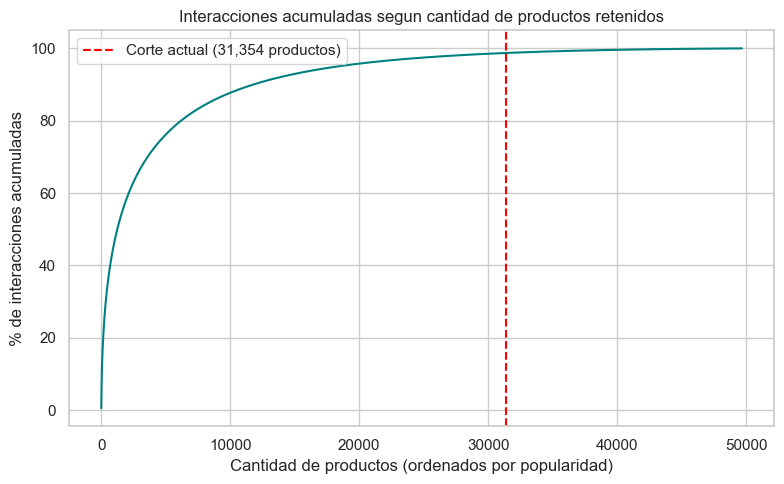

Con min_compras_producto=20, se conserva el 98.73% de las interacciones


In [5]:
# Curva acumulada: que % de interacciones se conserva segun el umbral de producto
pp_sorted = product_popularity.sort_values(ascending=False)
cum_pct = pp_sorted.cumsum() / pp_sorted.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(cum_pct)), cum_pct.values, color='teal')
ax.axvline((product_popularity >= min_compras_producto).sum(), color='red', linestyle='--',
           label=f'Corte actual ({(product_popularity >= min_compras_producto).sum():,} productos)')
ax.set_title('Interacciones acumuladas segun cantidad de productos retenidos')
ax.set_xlabel('Cantidad de productos (ordenados por popularidad)')
ax.set_ylabel('% de interacciones acumuladas')
ax.legend()
plt.tight_layout()
plt.show()

pct_conservado = cum_pct.iloc[(product_popularity >= min_compras_producto).sum() - 1]
print(f"Con min_compras_producto={min_compras_producto}, se conserva el {pct_conservado:.2f}% de las interacciones")

## 3. Reducción de Ruido y Filtrado
Las gráficas anteriores evidencian una fuerte dispersión: muchos usuarios han comprado muy pocos productos y una gran cola de productos se ha vendido rara vez. Filtramos la matriz para retener solo información con suficiente densidad estadística.

In [6]:
interactions_clean = interactions.copy()
prev_len = -1
iteracion = 0

while len(interactions_clean) != prev_len:
    prev_len = len(interactions_clean)
    iteracion += 1

    ua = interactions_clean.groupby('user_id').size()
    pp = interactions_clean.groupby('product_id').size()

    usuarios_activos = ua[ua >= min_compras_usuario].index
    productos_populares = pp[pp >= min_compras_producto].index

    interactions_clean = interactions_clean[
        interactions_clean['user_id'].isin(usuarios_activos) &
        interactions_clean['product_id'].isin(productos_populares)
    ]

    print(f"  Iteracion {iteracion}: {len(interactions_clean):,} registros")

registros_finales = len(interactions_clean)
print(f"\nRegistros tras la limpieza (convergencia en {iteracion} iteraciones): {registros_finales:,}")
print(f"Reduccion total: {(1 - registros_finales / len(interactions)) * 100:.2f}%")


  Iteracion 1: 13,129,642 registros
  Iteracion 2: 13,129,246 registros
  Iteracion 3: 13,129,246 registros

Registros tras la limpieza (convergencia en 3 iteraciones): 13,129,246
Reduccion total: 1.34%


## 4. Mapeo Categórico de IDs y Exportación
Para optimizar el uso de la memoria ram en la implementación concurrente en Go, transformamos los IDs de usuarios y productos en índices contiguos (0 a N-1). Finalmente, exportamos la matriz numérica y el diccionario descriptivo.

In [7]:
print("Mapeando IDs a indices contiguos...")
user_cat = interactions_clean['user_id'].astype('category')
item_cat = interactions_clean['product_id'].astype('category')

interactions_clean['user_index'] = user_cat.cat.codes
interactions_clean['item_index'] = item_cat.cat.codes

# Exportar matriz principal
matriz_exportar = interactions_clean[['user_index', 'item_index', 'purchase_count']]
matriz_exportar.to_csv("instacart_matriz_limpia.csv", index=False)

# Crear y exportar diccionario de productos
item_mapping = pd.DataFrame({
    'item_index': range(len(item_cat.cat.categories)),
    'product_id': item_cat.cat.categories
})
item_mapping = pd.merge(item_mapping, products_df, on="product_id", how="left")
item_mapping[['item_index', 'product_name']].to_csv("productos_mapeados.csv", index=False)

# Metadata para el backend en Go (pre-alocacion de slices)
n_users = len(user_cat.cat.categories)
n_items = len(item_cat.cat.categories)
with open("matriz_meta.json", "w") as f:
    json.dump({"n_users": n_users, "n_items": n_items, "n_interactions": len(matriz_exportar)}, f, indent=2)

end_time = time.time()
print(f"n_users={n_users:,} | n_items={n_items:,}")
print(f"Proceso finalizado exitosamente en {round(end_time - start_time, 2)} segundos.")
print("-> Generados: 'instacart_matriz_limpia.csv', 'productos_mapeados.csv' y 'matriz_meta.json'")

Mapeando IDs a indices contiguos...
n_users=202,775 | n_items=31,351
Proceso finalizado exitosamente en 36.41 segundos.
-> Generados: 'instacart_matriz_limpia.csv', 'productos_mapeados.csv' y 'matriz_meta.json'
